In [89]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
from urllib.parse import urlparse
import warnings
import pyphen
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

dic = pyphen.Pyphen(lang='es')
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
sns.set_palette('husl')

warnings.filterwarnings('ignore')

print("Setup complete!")



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1861.46it/s]
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Setup complete!


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2625.25it/s]


In [90]:
import re

# Functions to calculate the Fernández-Huerta index
def count_syllables(word):
    word = word.lower()
    # Normalize critical diacritics
    replacements = {'á':'a', 'é':'e', 'í':'i', 'ó':'o', 'ú':'u', 'ü':'u'}
    for k, v in replacements.items():
        word = word.replace(k, v)
    # Using a hyphenation dictionary (pyphen) to count syllables
    return max(dic.inserted(word).count('-') + 1, 1)

def calculate_fernandez_huerta_readability(text):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    
    if not sentences:
        return {
            "FH_index": None,
            "readability_level": "No valid sentences",
            "syllables_per_word": None,
            "words_per_sentence": None
        }

    words = [w for s in sentences for w in re.findall(r'\b\w+\b', s)]
    total_words = len(words)

    if total_words == 0:
        return {
            "FH_index": None,
            "readability_level": "No words",
            "syllables_per_word": None,
            "words_per_sentence": None
        }

    total_syllables = sum(count_syllables(w) for w in words)
    syllables_per_word = total_syllables / total_words
    words_per_sentence = total_words / len(sentences)

    # Fernández-Huerta Formula
    index = 206.84 - (60 * syllables_per_word) - (1.02 * words_per_sentence)
    
    if index >= 90:
        classification = "Very easy"
    elif 80 <= index < 90:
        classification = "Easy"
    elif 70 <= index < 80:
        classification = "Somewhat easy"
    elif 60 <= index < 70:
        classification = "Normal (for adults)"
    elif 50 <= index < 60:
        classification = "Somewhat difficult"
    elif 30 <= index < 50:
        classification = "Difficult"
    else:
        classification = "Very difficult"

    return {
        "FH_index": index,
        "readability_level": classification,
        "syllables_per_word": syllables_per_word,
        "words_per_sentence": words_per_sentence
    }

def calculate_similarity(text1, text2):
    try:
        # Cosine with CountVectorizer (Bag of Words)
        vectorizer = CountVectorizer()
        vectors = vectorizer.fit_transform([text1, text2]).toarray()
        count_cosine = cosine_similarity(vectors)[0][1]

        # Cosine with Embeddings
        text1_vector = model.encode(text1)
        text2_vector = model.encode(text2)
        embeddings_cosine = cosine_similarity([text1_vector], [text2_vector])[0][0]

        # Average of similarities
        average_similarity = (count_cosine + embeddings_cosine) / 2

        return average_similarity
    except Exception as e:
        print(f"Error calculating similarity: {e}")
        return 0



In [91]:
# Load the analysis-ready datasets
df = pd.read_csv('../data/part3/part3_analysis_ready.csv', encoding='utf-8-sig')
tools_df = pd.read_csv('../data/part3/part3_tools_long.csv', encoding='utf-8-sig')

print(f"Analysis-ready dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Tool-long dataset shape: {tools_df.shape[0]} rows × {tools_df.shape[1]} columns")
print("\nKey canonical columns:")
print([
    'row_id', 'group_id', 'document_name_clean', 'language_code',
    'tools_normalized', 'tool_family', 'has_original_text',
    'has_proposal_text', 'is_duplicate_exact', 'quality_flags'
])


Analysis-ready dataset shape: 66 rows × 36 columns
Tool-long dataset shape: 90 rows × 7 columns

Key canonical columns:
['row_id', 'group_id', 'document_name_clean', 'language_code', 'tools_normalized', 'tool_family', 'has_original_text', 'has_proposal_text', 'is_duplicate_exact', 'quality_flags']


In [92]:
# Display analysis-ready dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   row_id                             66 non-null     str    
 1   group_id                           66 non-null     int64  
 2   document_name_raw                  66 non-null     str    
 3   document_name_clean                66 non-null     str    
 4   language_raw                       52 non-null     str    
 5   language_code                      66 non-null     str    
 6   language_label                     66 non-null     str    
 7   tool_raw                           63 non-null     str    
 8   tools_normalized                   62 non-null     str    
 9   tool_primary                       62 non-null     str    
 10  tool_secondary                     24 non-null     str    
 11  tool_count                         66 non-null     int64  
 12  tool_fa

In [93]:
df.head(3)


,row_id,group_id,document_name_raw,document_name_clean,language_raw,language_code,language_label,tool_raw,tools_normalized,tool_primary,tool_secondary,tool_count,tool_family,original_text_raw,original_text_clean,proposal_text_raw,proposal_text_clean,comments_raw,comments_clean,has_original_text,has_proposal_text,has_comments,is_analysis_pair,is_duplicate_exact,duplicate_exact_group_size,is_duplicate_semantic_candidate,duplicate_semantic_group_size,original_text_fingerprint,proposal_text_fingerprint,original_char_len,proposal_char_len,comments_char_len,original_word_count,proposal_word_count,length_ratio_proposal_vs_original,quality_flags
0,part3-8843937d431ee998,1,2020 Guide for International Students UPM,2020 guide for international students upm,English,en,English,"Gemini, ChatGPT",Gemini | ChatGPT,Gemini,ChatGPT,2,llm,1. INTRODUCTION \n1.1. THE UNIVERSITY \nMost U...,introduction\nthe university\nmost universidad...,1. INTRODUCTION\n\n1.1. THE UNIVERSITY\nThe Un...,introduction\nthe university\nthe universidad ...,"[{""orig"": ""1. INTRODUCTION \n1.1. THE UNIVERSI...","[{""orig"": ""introduction\nthe university\nmost ...",True,True,True,True,False,1,False,1,introductiontheuniversitymostuniversidadpolité...,introductiontheuniversitytheuniversidadpolitéc...,5235,2105,8727,837,375,0.448029,multi_tool
1,part3-0ad6e628c35a156c,1,2013 Self Assessment,2013 self assessment,English,en,English,"Gemini, ChatGPT",Gemini | ChatGPT,Gemini,ChatGPT,2,llm,University of Manchester two year self-assessm...,university of manchester two year self-assessm...,1. INTRODUCTION\n\nThe University of Mancheste...,introduction\nthe university of manchester rec...,"[{""orig"": ""University of Manchester two year s...","[{""orig"": ""university of manchester two year s...",True,True,True,True,False,1,False,1,universityofmanchestertwoyearselfassessmentfor...,introductiontheuniversityofmanchesterreceiveda...,5598,2638,10612,859,443,0.515716,multi_tool
2,part3-c22b36c4d7b544f4,3,University of Manchester HR Excellence in Rese...,university of manchester hr excellence in rese...,English,en,English,Gemini,Gemini,Gemini,NaN,1,llm,1\nUniversity of Manchester HR Excellence in R...,1\nuniversity of manchester hr excellence in r...,This report explains how the University of Man...,this report explains how the university of man...,"[{""orig"": ""1\nUniversity of Manchester HR Exce...","[{""orig"": ""1\nuniversity of manchester hr exce...",True,True,True,True,False,1,False,1,1universityofmanchesterhrexcellenceinresearcha...,thisreportexplainshowtheuniversityofmanchester...,15338,1485,17087,2407,281,0.116743,NaN


In [94]:
tools_df.head(10)

,row_id,group_id,document_name_clean,tool_position,tool_name,tool_member_family,tool_raw
0,part3-8843937d431ee998,1,2020 guide for international students upm,1.0,Gemini,llm,"Gemini, ChatGPT"
1,part3-8843937d431ee998,1,2020 guide for international students upm,2.0,ChatGPT,llm,"Gemini, ChatGPT"
2,part3-0ad6e628c35a156c,1,2013 self assessment,1.0,Gemini,llm,"Gemini, ChatGPT"
3,part3-0ad6e628c35a156c,1,2013 self assessment,2.0,ChatGPT,llm,"Gemini, ChatGPT"
4,part3-c22b36c4d7b544f4,3,university of manchester hr excellence in rese...,1.0,Gemini,llm,Gemini
5,part3-0097232e8c401877,3,university of manchester hr excellence in rese...,1.0,ChatGPT,llm,ChatGPT
6,part3-b6d3fb477edfdda0,4,university of manchester hr excellence in rese...,1.0,ChatGPT,llm,ChatGPT based on GPT-5.2
7,part3-ae032ddba92b30a0,4,2020 upm guide for international students,1.0,Gemini,llm,Gemini Pro 3
8,part3-d0444633a04e9450,5,university of manchester two year self-assessm...,1.0,ChatGPT,llm,ChatGPT 5.2 through Perplexity Pro
9,part3-d0444633a04e9450,5,university of manchester two year self-assessm...,2.0,Perplexity,llm,ChatGPT 5.2 through Perplexity Pro


## Section 1: Descriptive Analysis

In this section, we explore the general characteristics of the Part 3 dataset, focusing on language distribution, tool usage, and overall text lengths.

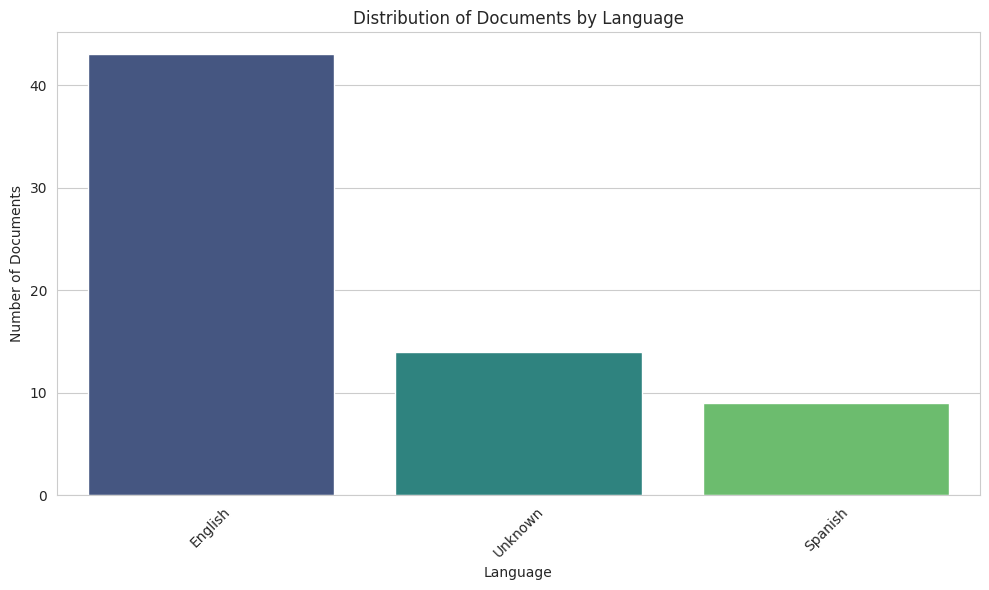

In [95]:
# 1.1 Language Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='language_label', order=df['language_label'].value_counts().index, palette='viridis')
plt.title('Distribution of Documents by Language')
plt.xlabel('Language')
plt.ylabel('Number of Documents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

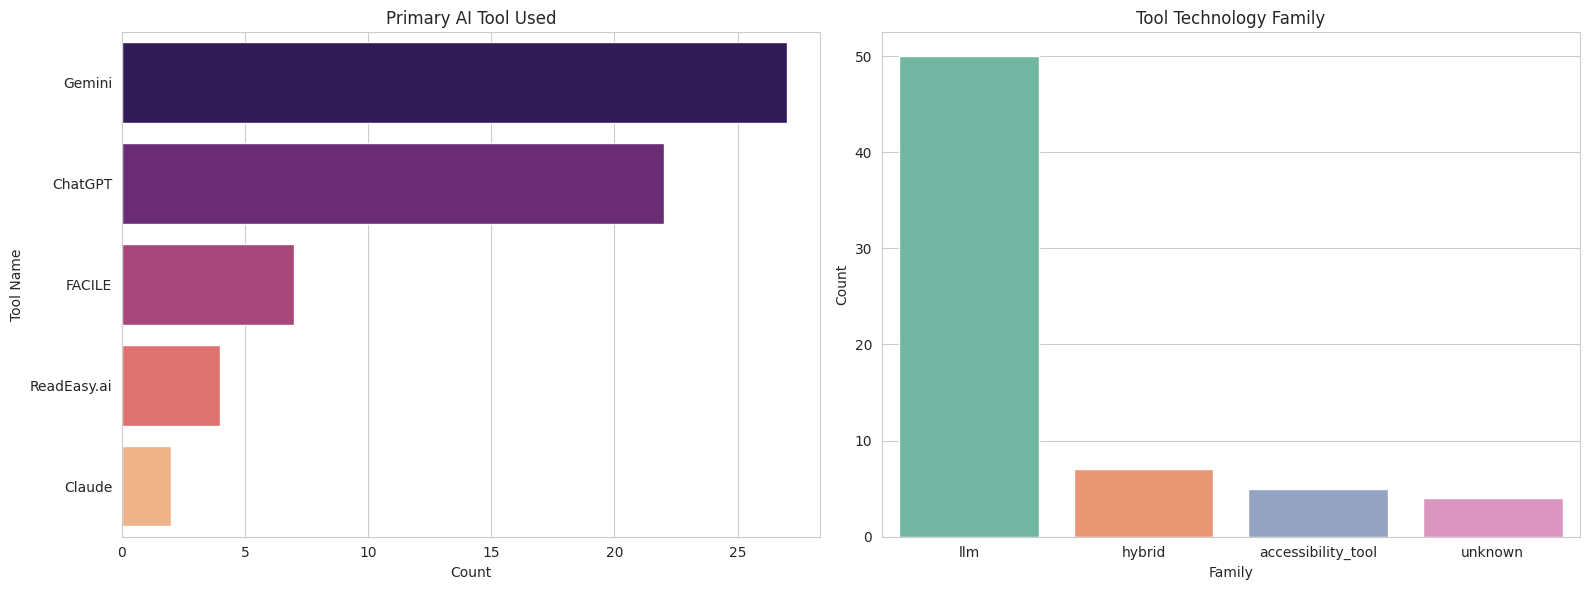

In [96]:
# 1.2 Tool Usage Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Primary Tool
sns.countplot(data=df, y='tool_primary', order=df['tool_primary'].value_counts().index, palette='magma', ax=ax1)
ax1.set_title('Primary AI Tool Used')
ax1.set_xlabel('Count')
ax1.set_ylabel('Tool Name')

# Tool Family
sns.countplot(data=df, x='tool_family', order=df['tool_family'].value_counts().index, palette='Set2', ax=ax2)
ax2.set_title('Tool Technology Family')
ax2.set_xlabel('Family')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

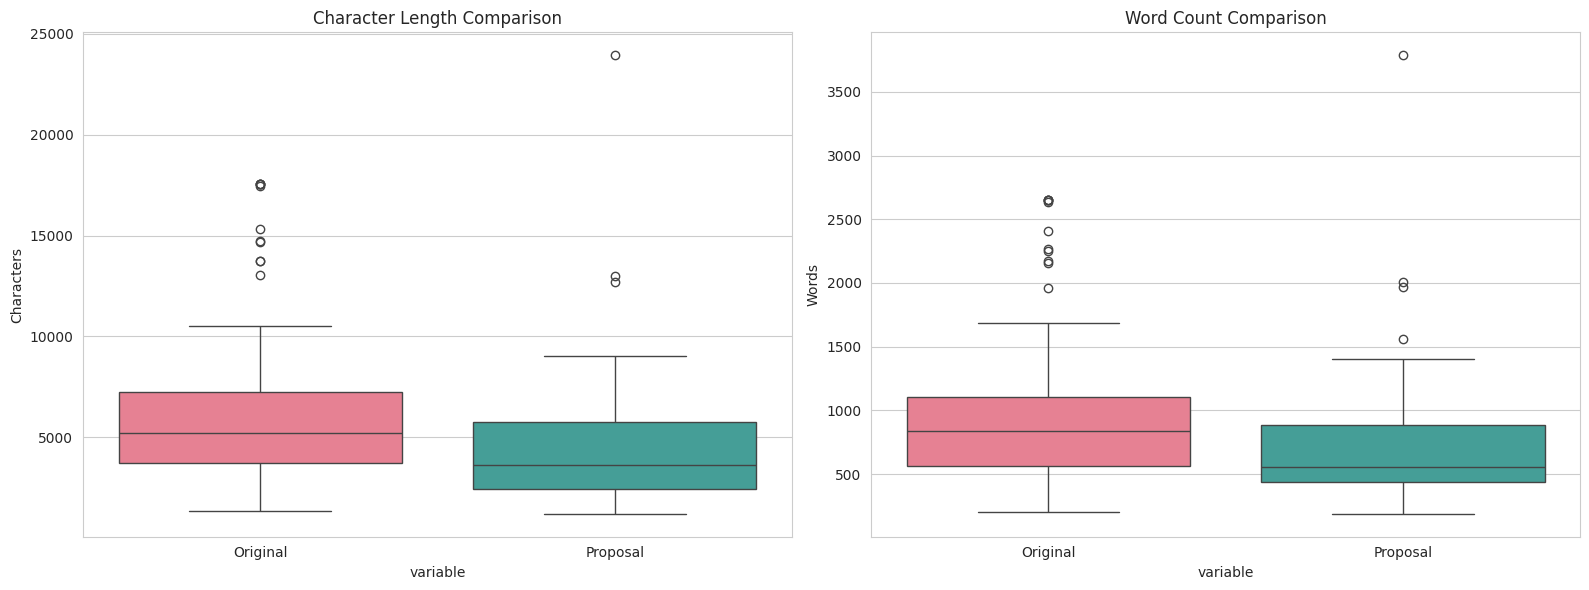

Median character reduction: 31.0%
Median word count reduction: 33.7%


In [97]:
# 1.3 Text Length Analysis (Original vs Proposal)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Character Length Comparison
length_data = df[['original_char_len', 'proposal_char_len']].melt()
sns.boxplot(data=length_data, x='variable', y='value', palette='husl', ax=ax1)
ax1.set_title('Character Length Comparison')
ax1.set_xticklabels(['Original', 'Proposal'])
ax1.set_ylabel('Characters')

# Word Count Comparison
word_data = df[['original_word_count', 'proposal_word_count']].melt()
sns.boxplot(data=word_data, x='variable', y='value', palette='husl', ax=ax2)
ax2.set_title('Word Count Comparison')
ax2.set_xticklabels(['Original', 'Proposal'])
ax2.set_ylabel('Words')

plt.tight_layout()
plt.show()

# Get median character reduction
char_reduction = (1 - df['proposal_char_len'].median() / df['original_char_len'].median()) * 100
word_reduction = (1 - df['proposal_word_count'].median() / df['original_word_count'].median()) * 100
print(f"Median character reduction: {char_reduction:.1f}%")
print(f"Median word count reduction: {word_reduction:.1f}%")

## Section 2: Readability Analysis (Fernández-Huerta)

We apply the Fernández-Huerta index to both original and simplified texts to quantify the impact of the tools on text complexity.

In [98]:
# 2.1 Calculate FH index for both versions
print("Calculating Readability Indices...")
df['readability_original_fh'] = df['original_text_clean'].apply(lambda x: calculate_fernandez_huerta_readability(str(x))['FH_index'] if pd.notnull(x) else None)
df['readability_proposal_fh'] = df['proposal_text_clean'].apply(lambda x: calculate_fernandez_huerta_readability(str(x))['FH_index'] if pd.notnull(x) else None)

# Print summary statistics
print("\nFernández-Huerta Index Summary (Original vs. Proposal):")
readability_summary = df[['readability_original_fh', 'readability_proposal_fh']].describe().transpose()
print(readability_summary[['mean', 'std', '50%', 'min', 'max']])

Calculating Readability Indices...

Fernández-Huerta Index Summary (Original vs. Proposal):
                              mean        std        50%        min         max
readability_original_fh  64.296979  10.559476  66.767404  38.957568   90.361409
readability_proposal_fh  86.990500  14.940959  84.355833  46.474113  115.958325


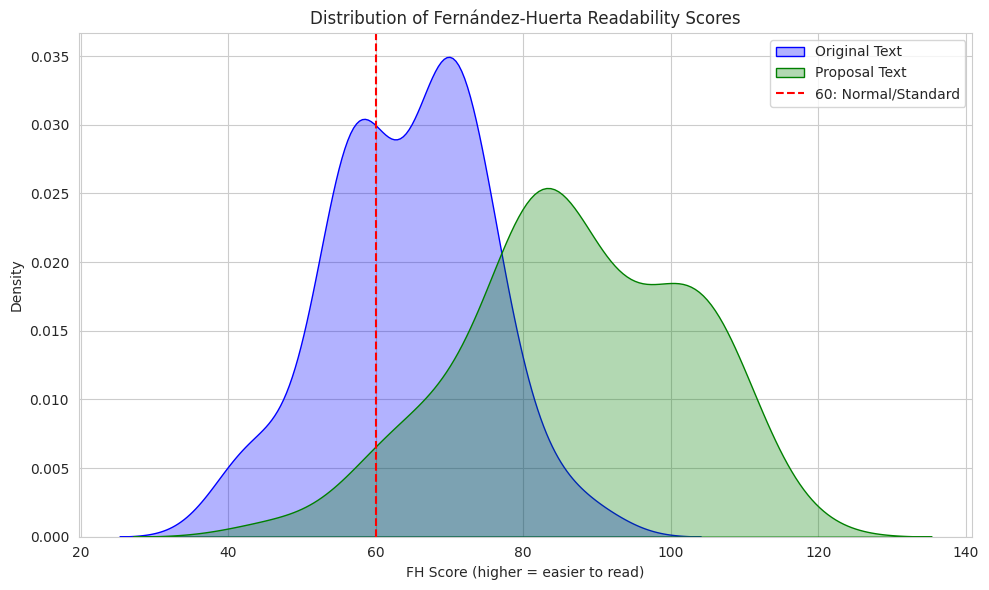

In [99]:
# 2.2 Distribution of FH Scores
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df['readability_original_fh'], label='Original Text', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=df['readability_proposal_fh'], label='Proposal Text', fill=True, color='green', alpha=0.3)
plt.title('Distribution of Fernández-Huerta Readability Scores')
plt.xlabel('FH Score (higher = easier to read)')
plt.ylabel('Density')
plt.axvline(60, color='red', linestyle='--', label='60: Normal/Standard')
plt.legend()
plt.tight_layout()
plt.show()

## Section 3: Semantic Similarity and Quality

Finally, we analyze the semantic alignment between original and proposal texts, and check the quality flags distribution.

Calculating similarity for balanced sample of 66 documents...

Semantic Similarity Statistics:
mean    0.802663
std     0.111918
50%     0.816113
Name: semantic_similarity, dtype: float64


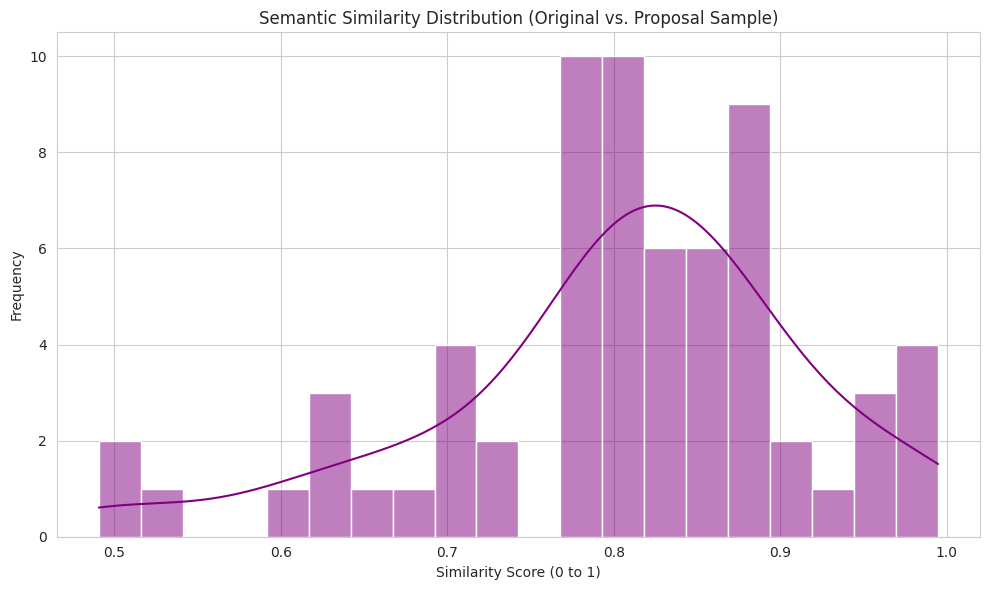

In [100]:
# 3.1 Calculate Semantic Similarity (Estimated as it is slow on large dataset)
sample_df = df[df['has_original_text'] & df['has_proposal_text']]
print(f"Calculating similarity for balanced sample of {len(sample_df)} documents...")

sample_df['semantic_similarity'] = sample_df.apply(lambda row: calculate_similarity(row['original_text_clean'], row['proposal_text_clean']), axis=1)

print("\nSemantic Similarity Statistics:")
print(sample_df['semantic_similarity'].describe()[['mean', 'std', '50%']])

# Visualize similarity distribution
plt.figure(figsize=(10, 6))
sns.histplot(sample_df['semantic_similarity'], kde=True, color='purple', bins=20)
plt.title('Semantic Similarity Distribution (Original vs. Proposal Sample)')
plt.xlabel('Similarity Score (0 to 1)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

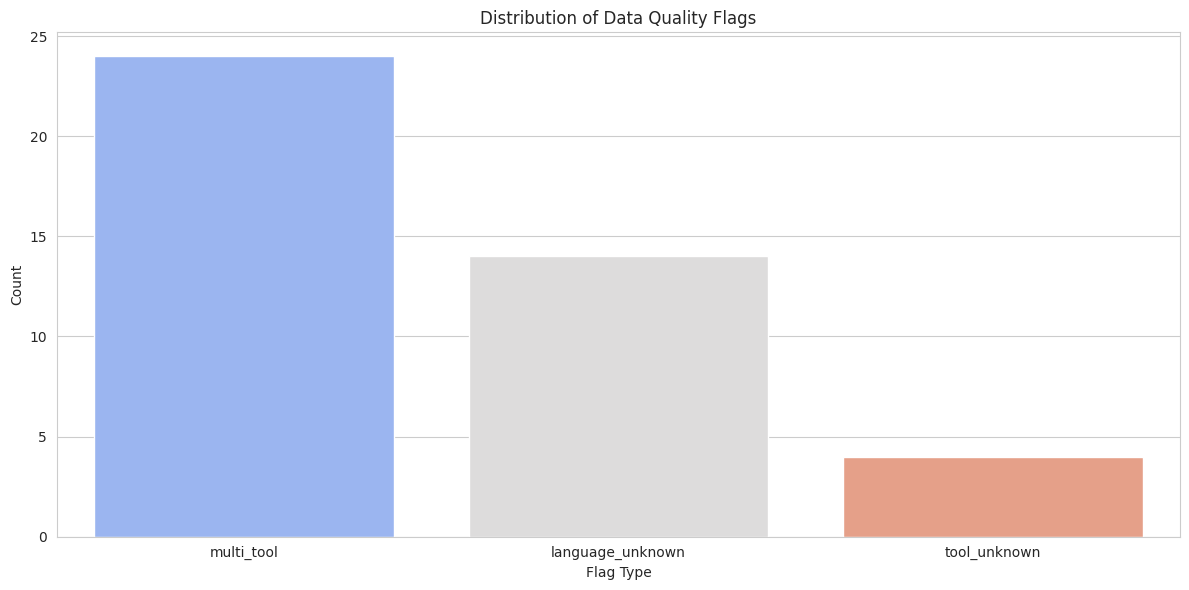


Top Group Contributions (by document count):
group_id
10    4
11    4
19    4
20    4
1     2
Name: count, dtype: int64


In [101]:
# 3.2 Quality Flags and Conclusion
plt.figure(figsize=(12, 6))
# Explode multi-flags for counting
flags_split = df['quality_flags'].str.split('|').explode().value_counts()
sns.barplot(x=flags_split.index, y=flags_split.values, palette='coolwarm')
plt.title('Distribution of Data Quality Flags')
plt.xlabel('Flag Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Final summary statistics by group_id top users
print("\nTop Group Contributions (by document count):")
print(df['group_id'].value_counts().head(5))

In [102]:
# 1.3 Calculate Readability Indices (Fernández-Huerta)

def extract_fh_score(text):
    if not isinstance(text, str) or text == "":
        return None
    return calculate_fernandez_huerta_readability(text)["FH_index"]

print("Calculating readability indices for original and proposal texts...")
df['readability_original_fh'] = df['original_text_clean'].apply(extract_fh_score)
df['readability_proposal_fh'] = df['proposal_text_clean'].apply(extract_fh_score)

# Calculate improvement
df['readability_improvement'] = df['readability_proposal_fh'] - df['readability_original_fh']

# Filter for rows that have both indices for comparative analysis
readability_df = df.dropna(subset=['readability_original_fh', 'readability_proposal_fh'])

print(f"Readability analysis dataset: {readability_df.shape[0]} valid pairs.")
display(readability_df[['readability_original_fh', 'readability_proposal_fh', 'readability_improvement']].describe())

Calculating readability indices for original and proposal texts...
Readability analysis dataset: 66 valid pairs.


,readability_original_fh,readability_proposal_fh,readability_improvement
count,66.000000,66.000000,66.000000
mean,64.296979,86.990500,22.693521
std,10.559476,14.940959,13.462285
min,38.957568,46.474113,1.549689
25%,57.362164,79.147730,11.896189
50%,66.767404,84.355833,21.581102
75%,70.970547,100.653689,30.981537
max,90.361409,115.958325,55.112335


## Section 2: Readability Analysis (Fernández-Huerta Index)

The Fernández-Huerta index measures the readability of Spanish text (though here applied to all languages for standardized comparison). Higher values indicate easier readability (90+ is very easy, <30 is very difficult).

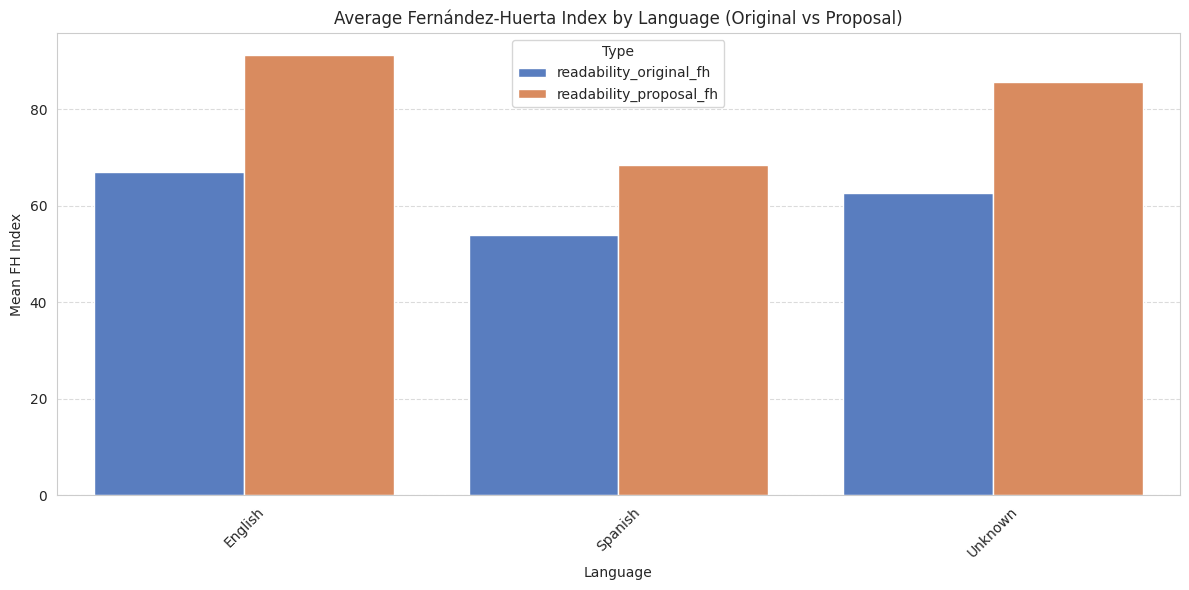

In [103]:
# 2.1 Fernández Index by Language
lang_readability = readability_df.groupby('language_label')[['readability_original_fh', 'readability_proposal_fh']].mean().reset_index()
lang_readability_long = lang_readability.melt(id_vars='language_label', var_name='Type', value_name='FH_Index')

plt.figure(figsize=(12, 6))
sns.barplot(data=lang_readability_long, x='language_label', y='FH_Index', hue='Type', palette='muted')
plt.title('Average Fernández-Huerta Index by Language (Original vs Proposal)')
plt.xlabel('Language')
plt.ylabel('Mean FH Index')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

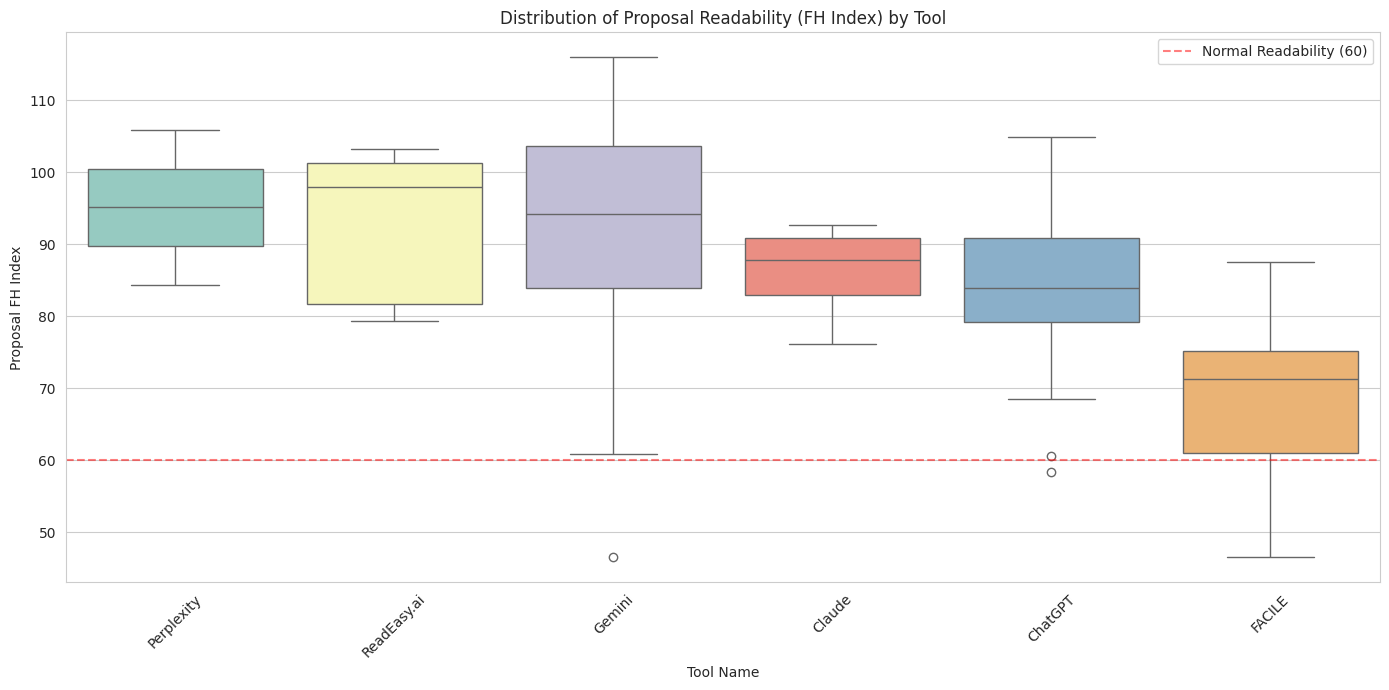

Top performing tools by Average Proposal Readability:


,tool_name,readability_proposal_fh,readability_improvement
0,Perplexity,95.108344,38.170795
1,ReadEasy.ai,92.723624,22.258137
2,Gemini,92.502751,28.917237
3,Claude,86.091748,24.155776
4,ChatGPT,83.967699,18.624046
5,FACILE,68.228059,9.525259


In [104]:
# 2.2 Fernández Index by Adaptation Tool
# We use tools_df joined with readability results for tool-specific analysis
tool_perf = tools_df.merge(readability_df[['row_id', 'readability_original_fh', 'readability_proposal_fh', 'readability_improvement']], on='row_id')
tool_readability = tool_perf.groupby('tool_name')[['readability_original_fh', 'readability_proposal_fh', 'readability_improvement']].mean().sort_values('readability_proposal_fh', ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.boxplot(data=tool_perf, x='tool_name', y='readability_proposal_fh', palette='Set3', order=tool_readability['tool_name'])
plt.title('Distribution of Proposal Readability (FH Index) by Tool')
plt.xlabel('Tool Name')
plt.ylabel('Proposal FH Index')
plt.xticks(rotation=45)
plt.axhline(60, color='red', linestyle='--', alpha=0.5, label='Normal Readability (60)')
plt.legend()
plt.tight_layout()
plt.show()

print("Top performing tools by Average Proposal Readability:")
display(tool_readability[['tool_name', 'readability_proposal_fh', 'readability_improvement']].head(10))

## Section 3: Text Size Reduction Analysis

Easy-to-Read (E2R) principles often involve simplifying and condensing text. This section analyzes how much the original text was reduced during the adaptation process.

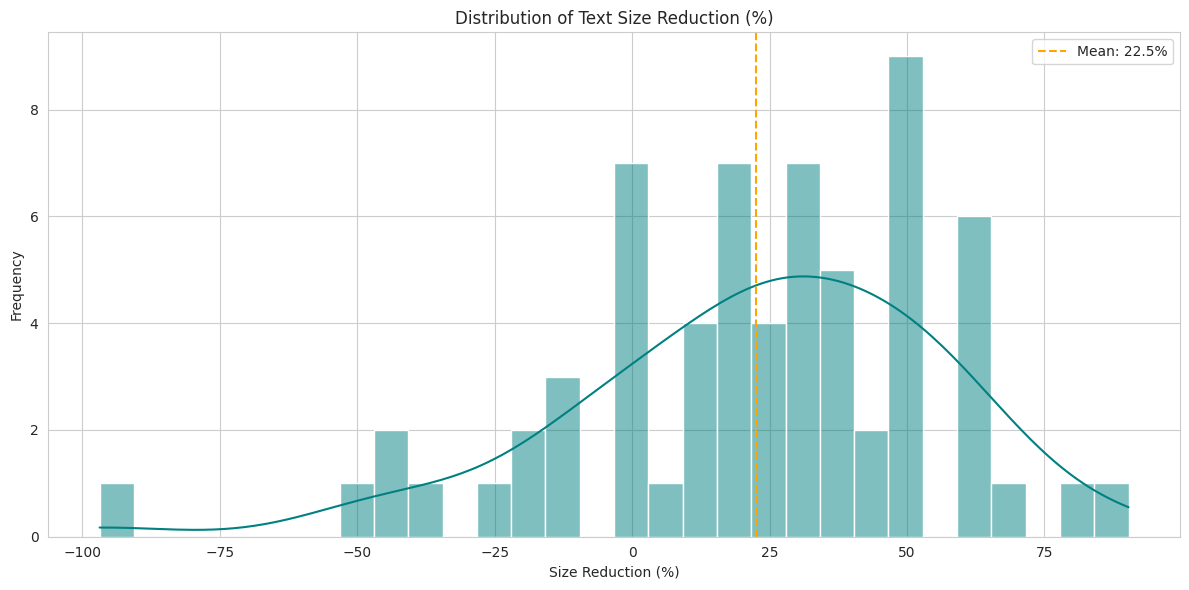

Average size reduction across all adaptations: 22.52%


In [105]:
# 3.1 Size Reduction Analysis
readability_df['size_reduction_pct'] = (1 - readability_df['proposal_char_len'] / readability_df['original_char_len']) * 100

plt.figure(figsize=(12, 6))
sns.histplot(data=readability_df, x='size_reduction_pct', kde=True, color='teal', bins=30)
plt.title('Distribution of Text Size Reduction (%)')
plt.xlabel('Size Reduction (%)')
plt.ylabel('Frequency')
plt.axvline(readability_df['size_reduction_pct'].mean(), color='orange', linestyle='--', label=f'Mean: {readability_df["size_reduction_pct"].mean():.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average size reduction across all adaptations: {readability_df['size_reduction_pct'].mean():.2f}%")

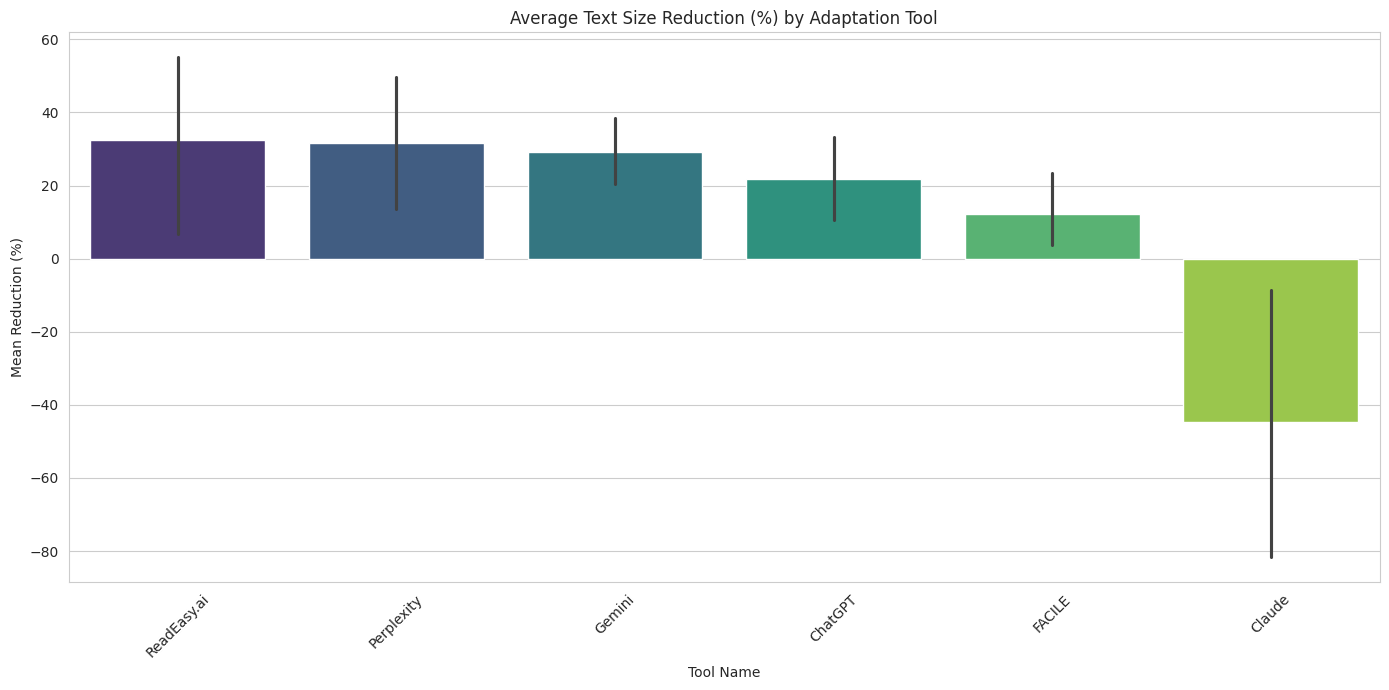

In [106]:
# 3.2 Size Reduction by Tool
tool_reduction = tool_perf.merge(df[['row_id', 'original_char_len', 'proposal_char_len']], on='row_id')
tool_reduction['size_reduction_pct'] = (1 - tool_reduction['proposal_char_len'] / tool_reduction['original_char_len']) * 100
tool_reduction_mean = tool_reduction.groupby('tool_name')['size_reduction_pct'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=tool_reduction, x='tool_name', y='size_reduction_pct', palette='viridis', order=tool_reduction_mean['tool_name'])
plt.title('Average Text Size Reduction (%) by Adaptation Tool')
plt.xlabel('Tool Name')
plt.ylabel('Mean Reduction (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Section 4: Comment-Based Qualitative Analysis

In this section, we analyze the students' qualitative comments to evaluate the E2R adaptation quality per tool. We use a keyword-based sentiment analysis to categorize feedback as Positive, Negative, or Neutral.

In [116]:
# Define sentiment keywords
POSITIVE_KEYWORDS = [
    'bien', 'correcto', 'mejor', 'adecuado', 'buen', 'ajusta', 'claro', 'sencillo', 
    'mejorado', 'excelente', 'perfecto', 'good', 'better', 'well', 'clear', 'simple'
]
NEGATIVE_KEYWORDS = [
    'error', 'mal', 'peor', 'incorrecto', 'no cumple', 'confuso', 'dificil', 
    'bad', 'worse', 'wrong', 'issue', 'alerta', 'erroneo', 'complejo', 'no se entiende'
]

def categorize_sentiment(text):
    if pd.isna(text) or text == "":
        return 'Neutral'
    
    text_lower = str(text).lower()
    pos_hits = sum(1 for kw in POSITIVE_KEYWORDS if kw in text_lower)
    neg_hits = sum(1 for kw in NEGATIVE_KEYWORDS if kw in text_lower)
    
    if pos_hits > neg_hits:
        return 'Positive'
    elif neg_hits > pos_hits:
        return 'Negative'
    else:
        return 'Neutral'


In [117]:
# 4.1 Extract and Categorize Comments
comment_rows = []

# Use the long format tools_df to associate tools with results
# Merge with the cleaned comments from the main df
tools_with_comments = tools_df.merge(df[['row_id', 'comments_clean']], on='row_id')

for _, row in tools_with_comments.iterrows():
    try:
        # Parse the JSON comments
        comments_list = json.loads(row['comments_clean'])
        for c_entry in comments_list:
            comment_text = c_entry.get('comment', '')
            if comment_text.strip():
                comment_rows.append({
                    'row_id': row['row_id'],
                    'tool_name': row['tool_name'],
                    'tool_family': row['tool_member_family'],
                    'comment': comment_text,
                    'sentiment': categorize_sentiment(comment_text)
                })
    except Exception as e:
        continue

comments_analysis_df = pd.DataFrame(comment_rows)
print(f"Analyzed {len(comments_analysis_df)} individual comments.")
comments_analysis_df.head()

Analyzed 714 individual comments.


,row_id,tool_name,tool_family,comment,sentiment
0,part3-8843937d431ee998,Gemini,llm,the final version is a combination of gemini a...,Positive
1,part3-8843937d431ee998,ChatGPT,llm,the final version is a combination of gemini a...,Positive
2,part3-0ad6e628c35a156c,Gemini,llm,we combined gemini and chatgpt to create this ...,Positive
3,part3-0ad6e628c35a156c,ChatGPT,llm,we combined gemini and chatgpt to create this ...,Positive
4,part3-c22b36c4d7b544f4,Gemini,llm,gemini needed to be provided with the entire l...,Neutral


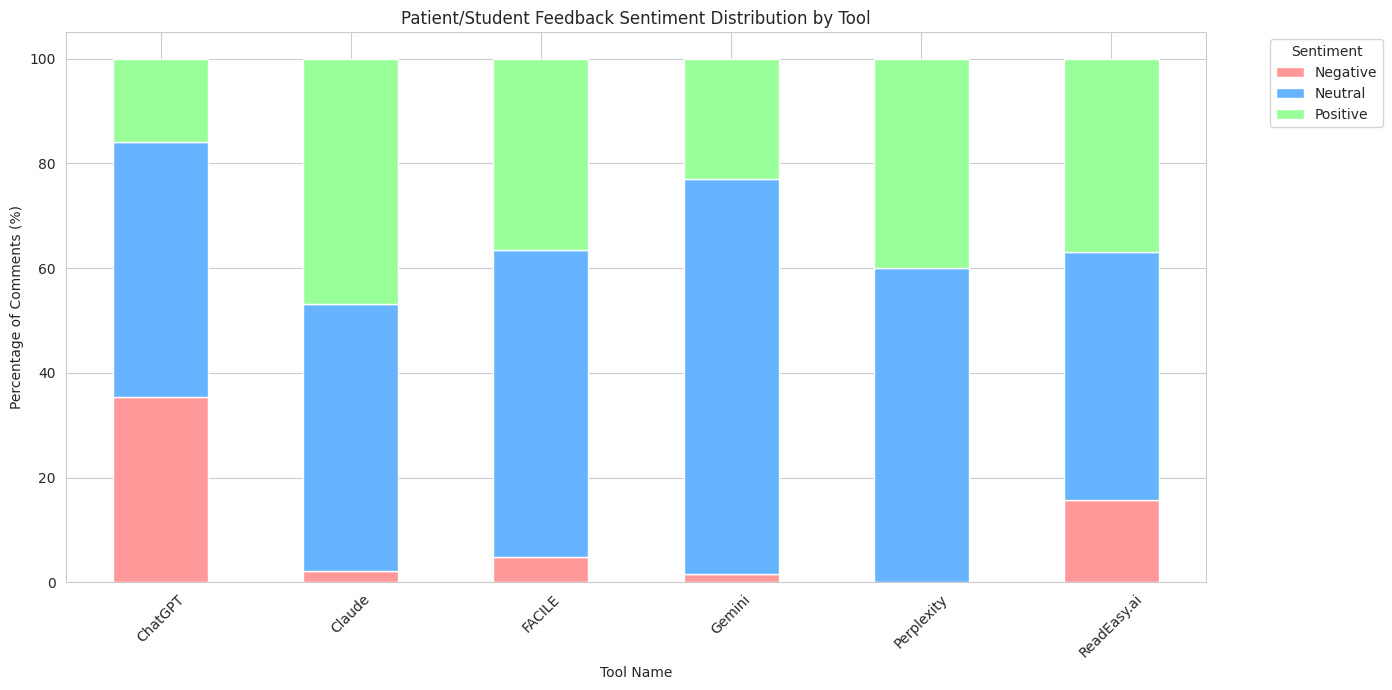

In [118]:
# 4.2 Sentiment Distribution by Tool
sentiment_by_tool = comments_analysis_df.groupby(['tool_name', 'sentiment']).size().unstack(fill_value=0)
# Normalize to percentages
sentiment_pct = sentiment_by_tool.div(sentiment_by_tool.sum(axis=1), axis=0) * 100

sentiment_pct.plot(kind='bar', stacked=True, figsize=(14, 7), color=['#ff9999','#66b3ff','#99ff99'])
plt.title('Patient/Student Feedback Sentiment Distribution by Tool')
plt.xlabel('Tool Name')
plt.ylabel('Percentage of Comments (%)')
plt.xticks(rotation=45)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [120]:
# 4.3 Key Insights from Comments
print("Best Results (Positive Feedback Insights):")
best_tools = sentiment_pct.sort_values('Positive', ascending=False).head(20)
display(best_tools)

print("\nMost Critical Issues (Negative Feedback Insights):")
worst_tools = sentiment_pct.sort_values('Negative', ascending=False).head(20)
display(worst_tools)

print("\nSample Critical Comments (Negative):")
display(comments_analysis_df[comments_analysis_df['sentiment'] == 'Negative'][['tool_name', 'comment']].head(20))

Best Results (Positive Feedback Insights):


sentiment,Negative,Neutral,Positive
tool_name,,,
Claude,2.127660,51.063830,46.808511
Perplexity,0.000000,60.000000,40.000000
ReadEasy.ai,15.789474,47.368421,36.842105
FACILE,4.878049,58.536585,36.585366
Gemini,1.597444,75.399361,23.003195
ChatGPT,35.460993,48.581560,15.957447



Most Critical Issues (Negative Feedback Insights):


sentiment,Negative,Neutral,Positive
tool_name,,,
ChatGPT,35.460993,48.581560,15.957447
ReadEasy.ai,15.789474,47.368421,36.842105
FACILE,4.878049,58.536585,36.585366
Claude,2.127660,51.063830,46.808511
Gemini,1.597444,75.399361,23.003195
Perplexity,0.000000,60.000000,40.000000



Sample Critical Comments (Negative):


,tool_name,comment
81,ChatGPT,removed passive voice.removed acronyms and hea...
141,ChatGPT,e2r issue: large numbers and complex organisat...
142,ChatGPT,e2r issue: long list in brackets increases cog...
143,ChatGPT,e2r issue: passive phrasing and abbreviation i...
144,ChatGPT,e2r issue: passive voice and abstract wording ...
145,ChatGPT,e2r issue: formal phrasing and relative clauses.
146,ChatGPT,e2r issue: vague academic phrasing (“diverse a...
147,ChatGPT,"e2r issue: abstract phrasing (“recognises”, “s..."
148,ChatGPT,e2r issue: abstract concept (“vision and strat...
149,ChatGPT,e2r issue: quoted promotional language and mul...


## Section 5: Data Export

In [132]:
## Section 5: Data Export
# Export comments to Excel for manual review and qualitative analysis

export_rows = []
for _, row in df.iterrows():
    try:
        # Parse the JSON comments from the consolidated column
        comments_list = json.loads(row['comments_clean'])
        tools_used = row["tools_normalized"]
        for c_entry in comments_list:
            export_rows.append({
                'group_id': row['group_id'],
                'document_name': row['document_name_clean'],
                'original_sentence': c_entry.get('orig', ''),
                'proposal_sentence': c_entry.get('prop', ''),
                'comment': c_entry.get('comment', ''),
                "tools_used": tools_used
            })
    except Exception as e:
        continue

comments_export_df = pd.DataFrame(export_rows)

# Save to Excel in the data/ folder
output_excel_path = '../data/part3/part3_comments_export.xlsx'
comments_export_df.to_excel(output_excel_path, index=False)

print(f"Successfully exported {len(comments_export_df)} comments to {output_excel_path}")
comments_export_df.head()

Successfully exported 586 comments to ../data/part3/part3_comments_export.xlsx


,group_id,document_name,original_sentence,proposal_sentence,comment,tools_used
0,1,2020 guide for international students upm,introduction\nthe university\nmost universidad...,introduction\nthe university\nthe universidad ...,the final version is a combination of gemini a...,Gemini | ChatGPT
1,1,2013 self assessment,university of manchester two year self-assessm...,introduction\nthe university of manchester rec...,we combined gemini and chatgpt to create this ...,Gemini | ChatGPT
2,3,university of manchester hr excellence in rese...,1\nuniversity of manchester hr excellence in r...,this report explains how the university of man...,gemini needed to be provided with the entire l...,Gemini
3,3,university of manchester hr excellence in rese...,1\nuniversity of manchester hr excellence in r...,what this document is about\nthis document exp...,chatgpt was trained for this in the same chat ...,ChatGPT
4,4,university of manchester hr excellence in rese...,"research associates and research fellows, and ...",these people work in:\nteaching\nresearch\nsup...,changed comma separated list to bullet points,ChatGPT
